# Explainable Multiclass Lung Disease Classification from Chest X-Ray Images


### This notebook presents an end-to-end deep learning pipeline for multiclass classification of chest X-ray images. The workflow includes data preprocessing, image augmentation using the albumentations library ,model training, validation and performance evaluation. Finally, LIME is used to provide visual explanations of the model's predictions and identify the image regions that contribute to each classification decision.

### 1. Libraries and Dependencies

### ***Import the libraries required for data preprocessing, model training, evaluation, visualization, and LIME-based explainability.***

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import albumentations as A
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from skimage.measure import regionprops, label
from tabulate import tabulate
import matplotlib.pyplot as plt
from lime import lime_image

2026-10-02 22:21:07.841442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790979667.861979      83 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790979667.868430      83 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### 2. Preprocessing

### ***Define the dataset path, image dimensions, and batch size used for training.***

In [2]:

data_dir = '/kaggle/input/scidataset'
img_height = 224
img_width = 224
batch_size = 64



### ***Load the image paths, assign class labels, and retrieve the class names from the dataset directories.***

In [3]:

def get_image_paths_and_labels(data_dir):
    class_names = sorted(os.listdir(data_dir))
    image_paths = []
    labels = []
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_path, fname))
                labels.append(label)
    return image_paths, labels, class_names

image_paths, labels, class_names = get_image_paths_and_labels(data_dir)

### ***Split the dataset into training, validation, and test sets while preserving the class distribution.***

In [4]:

X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, test_size=0.15, stratify=labels, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

### ***Define image preprocessing and augmentation transformations using Albumentations for training and validation.***

In [5]:
train_transform = A.Compose([
    A.Resize(img_height, img_width),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=15, p=0.3),
    A.Normalize()
])

val_transform = A.Compose([
    A.Resize(img_height, img_width),
    A.Normalize()
])

### ***Load and preprocess X-ray images in grayscale, apply the appropriate transformations, and prepare them for model input.***

In [6]:

def load_and_preprocess(image_path, label, is_train):
    image = cv2.imread(image_path.decode(), cv2.IMREAD_GRAYSCALE)  
    transform = train_transform if is_train else val_transform
    augmented = transform(image=image)
    image = augmented['image']
    image = np.expand_dims(image, axis=-1)  
    return image.astype(np.float32), label

### ***Integrate the preprocessing function into the TensorFlow data pipeline using tf.data.***


In [7]:

def tf_preprocess(image_path, label, is_train):
    def wrapper(image_path, label):
        return load_and_preprocess(image_path, label, is_train)
    
    image, label = tf.numpy_function(
        wrapper,
        inp=[image_path, label],
        Tout=[tf.float32, tf.int32]
    )
    image.set_shape([img_height, img_width, 1])  
    label.set_shape([])
    return image, label

### ***Create TensorFlow datasets for training, validation, and testing with preprocessing and efficient data loading.***

In [8]:

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(1000).map(lambda x, y: tf_preprocess(x, y, True), num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: tf_preprocess(x, y, False), num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: tf_preprocess(x, y, False), num_parallel_calls=tf.data.AUTOTUNE)


I0000 00:00:1790979731.697447      83 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790979731.700208      83 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### ***Batch and prefetch the datasets for efficient model training and evaluation.***

In [9]:

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Data succusseful prepared ")
print(f"Train: {len(X_train)} images | Val: {len(X_val)} images | Test: {len(X_test)} images")


Data succusseful prepared 
Train: 15492 images | Val: 3321 images | Test: 3320 images


### ***Visualize the number of images in each class to assess the dataset distribution.***

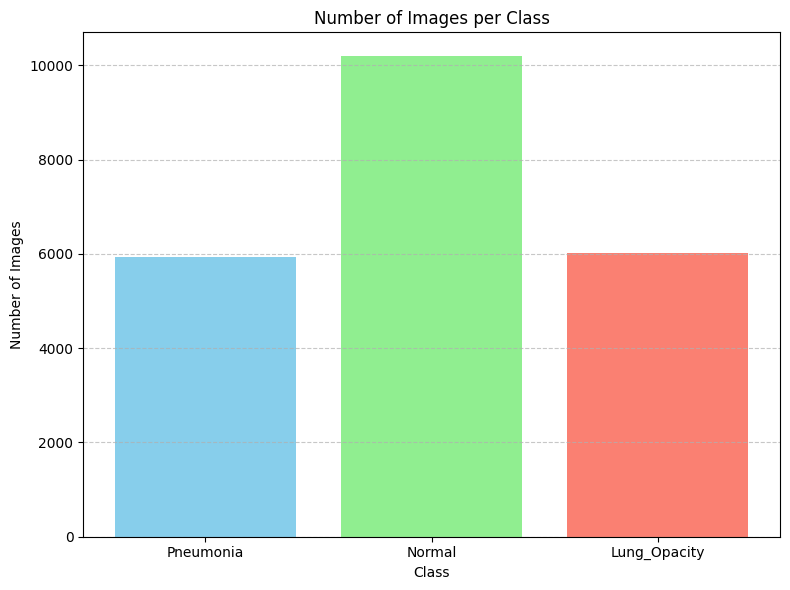

In [10]:


class_counts = {}

for class_name in os.listdir(data_dir):
    class_folder = os.path.join(data_dir, class_name)
    if os.path.isdir(class_folder):
        num_images = len([
            f for f in os.listdir(class_folder)
            if os.path.isfile(os.path.join(class_folder, f))
        ])
        class_counts[class_name] = num_images


classes = list(class_counts.keys())
counts = list(class_counts.values())

# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.bar(classes, counts, color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### ***Display a randomly selected image from the Normal class for visual inspection.***

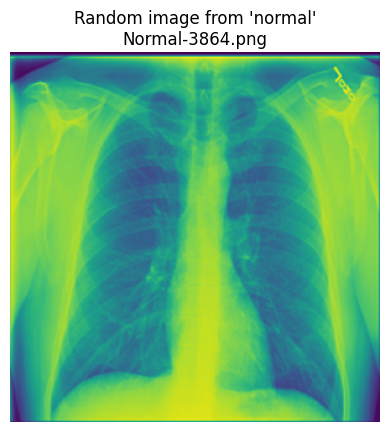

In [11]:
import random
import matplotlib.image as mpimg
normal_folder = '/kaggle/input/scidataset/Normal'


random_image = random.choice(os.listdir(normal_folder))
image_path = os.path.join(normal_folder, random_image)


img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.title(f"Random image from 'normal'\n{random_image}")
plt.show()


### 3. Model Architecture

### ***Define the CNN architecture with convolutional, pooling, fully connected, and dropout layers for multiclass classification.***

In [12]:

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### ***Compile the CNN model using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy metric.***

In [13]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


### ***Train the CNN model with early stopping based on validation accuracy.***

In [14]:

early_stopping = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)

history = cnn_model.fit(
    train_ds,  
    epochs=7,  
    validation_data=val_ds, 
    callbacks=[early_stopping]  
)

Epoch 1/7


I0000 00:00:1790979824.843780     170 service.cc:148] XLA service 0x7d3d24003b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790979824.844767     170 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1790979824.844788     170 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1790979825.393925     170 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/243 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.3789 - loss: 2.5479 

I0000 00:00:1790979833.135766     170 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


243/243 ━━━━━━━━━━━━━━━━━━━━ 61s 206ms/step - accuracy: 0.7329 - loss: 0.8832 - val_accuracy: 0.8838 - val_loss: 0.2940
Epoch 2/7
243/243 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.8680 - loss: 0.3332 - val_accuracy: 0.9045 - val_loss: 0.2458
Epoch 3/7
243/243 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step - accuracy: 0.8861 - loss: 0.2968 - val_accuracy: 0.9003 - val_loss: 0.2664
Epoch 4/7
243/243 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.8951 - loss: 0.2728 - val_accuracy: 0.9039 - val_loss: 0.2445


### ***Save the trained CNN model for later use and integrate it into a website.***

In [16]:
cnn_model.save("FinalModel.h5")

### ***Visualize the CNN architecture and training hyperparameters.***

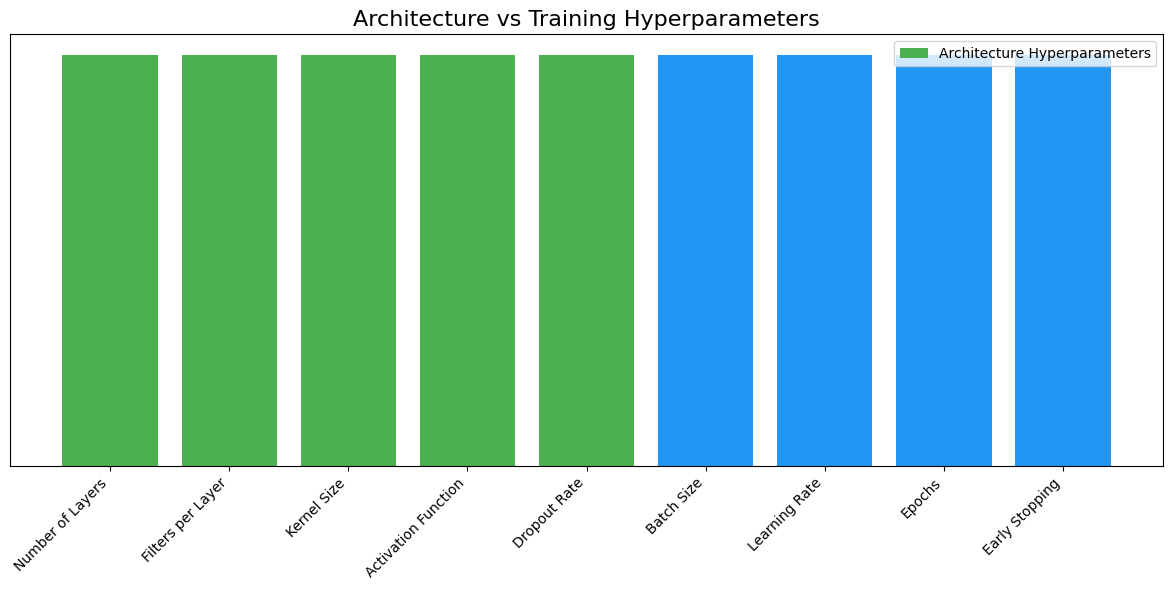

In [18]:
import matplotlib.pyplot as plt


categories = [
    'Number of Layers', 'Filters per Layer', 'Kernel Size',
    'Activation Function', 'Dropout Rate', 'Batch Size', 
    'Learning Rate', 'Epochs', 'Early Stopping'
]


types = [
    0, 0, 0,    
    0, 0,       
    1, 1, 1, 1  ]


colors = ['#4CAF50' if t == 0 else '#2196F3' for t in types]


plt.figure(figsize=(12, 6))
plt.bar(categories, [1]*len(categories), color=colors)
plt.title('Architecture vs Training Hyperparameters', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks([])
plt.legend(['Architecture Hyperparameters', 'Training Hyperparameters'], loc='upper right')
plt.tight_layout()
plt.show()


### ***Evaluate the model on the validation and test sets using loss and accuracy.***

In [19]:

val_loss, val_acc = cnn_model.evaluate(val_ds)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

test_loss, test_acc = cnn_model.evaluate(test_ds)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.9027 - loss: 0.2434
Validation Loss: 0.2458
Validation Accuracy: 0.9045
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.9032 - loss: 0.2468
Test Loss: 0.2427
Test Accuracy: 0.9048


### ***Generate the true labels, predicted classes, and prediction probabilities for the test set.***

In [ ]:

def get_labels_and_predictions(dataset, model):
    y_true = []
    y_pred = []
    y_proba = []

    for images, labels in dataset:
        predictions = model.predict(images)
        
        if predictions.shape[1] == 1:  # Classification binaire
            pred_labels = (predictions > 0.5).astype("int32").flatten()
            proba = predictions.flatten()
        else:  # Classification multi-classes
            pred_labels = np.argmax(predictions, axis=1)
            proba = np.max(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_labels)
        y_proba.extend(proba)

    return np.array(y_true), np.array(y_pred), np.array(y_proba)


y_true, y_pred, y_proba = get_labels_and_predictions(test_ds, cnn_model)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━

### ***Evaluate classification performance using the confusion matrix, classification report, and ROC-AUC when applicable.***

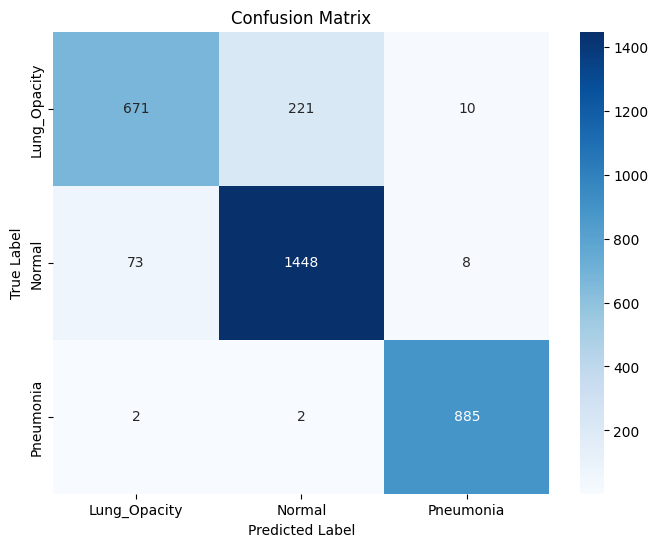

Classification Report:
              precision    recall  f1-score   support

Lung_Opacity       0.90      0.74      0.81       902
      Normal       0.87      0.95      0.90      1529
   Pneumonia       0.98      1.00      0.99       889

    accuracy                           0.90      3320
   macro avg       0.92      0.90      0.90      3320
weighted avg       0.91      0.90      0.90      3320



In [ ]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ROC Curve + AUC (only for binary classification)
if len(np.unique(y_true)) == 2:
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = roc_auc_score(y_true, y_proba)

    print(f"AUC Score: {auc_score:.4f}")

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

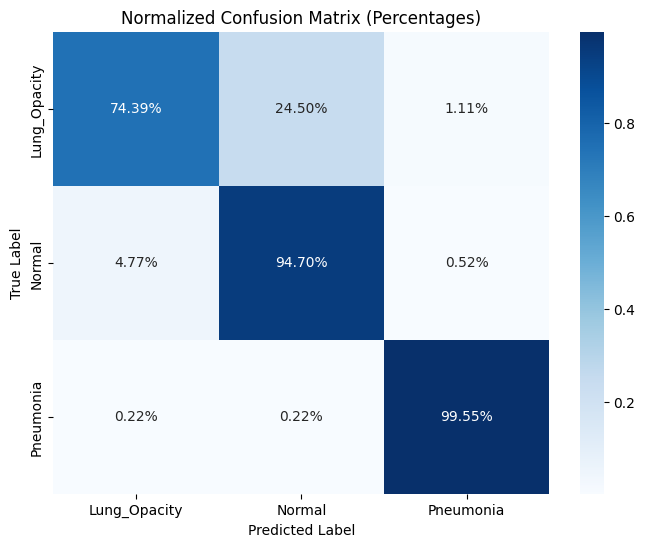

In [22]:

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Percentages)")
plt.show()


### ***Visualize training and validation accuracy and loss across epochs.***

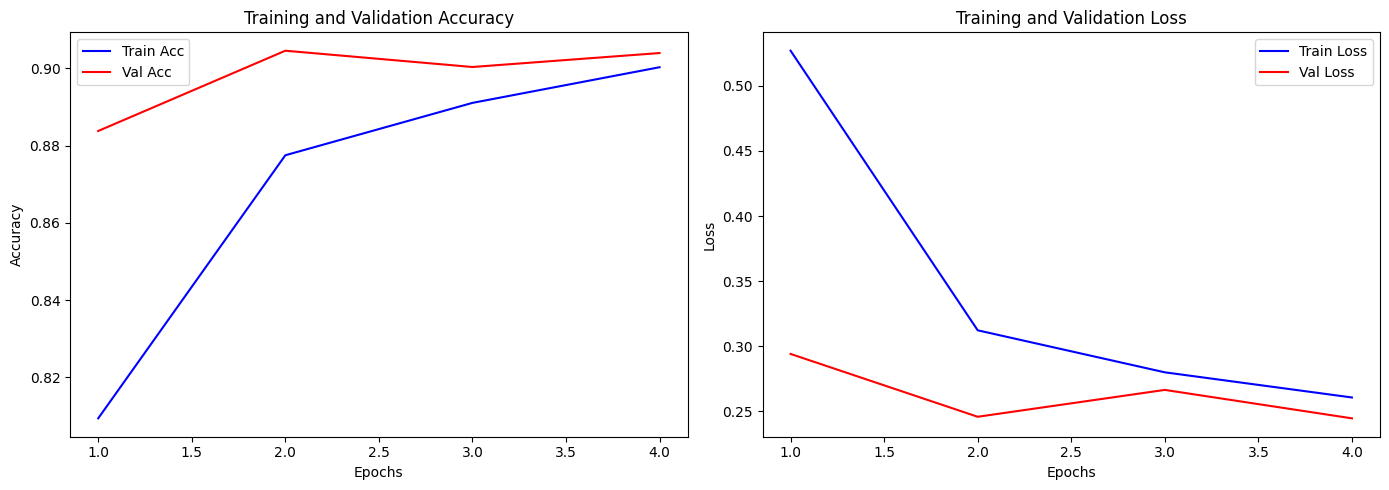

In [23]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Courbe de précision 
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Train Acc')  
plt.plot(epochs, val_acc, 'r-', label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Courbe de perte 
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Train Loss')
plt.plot(epochs, val_loss, 'r-', label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


### 3. LIME

In [24]:
pip install lime


Note: you may need to restart the kernel to use updated packages.


### ***Generate LIME explanations by highlighting image regions that influence the model's prediction.***

  0%|          | 0/2000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

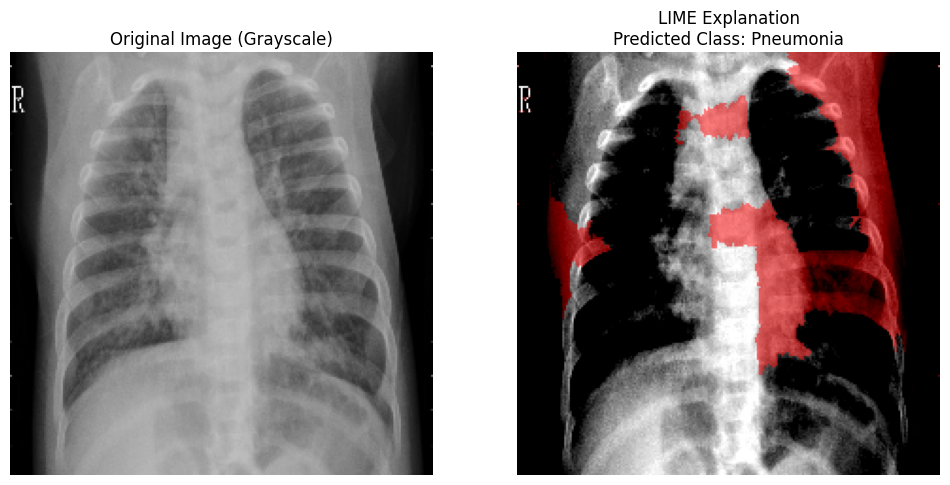

In [25]:
for images, labels in test_ds.take(15):
    sample_image = images[0].numpy()
    sample_label = labels[0].numpy()

def predict_fn(images):
    images_gray = np.mean(images, axis=-1, keepdims=True)
    return cnn_model.predict(images_gray)

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image=sample_image.squeeze().astype(np.double),
    classifier_fn=predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=2000
)

predicted_class = np.argmax(
    cnn_model.predict(np.expand_dims(sample_image, axis=0))
)

temp, mask = explanation.get_image_and_mask(
    label=predicted_class,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

img_original = sample_image.squeeze()
img_rgb = np.stack([img_original] * 3, axis=-1)

red_color = np.array([1, 0, 0])
alpha = 0.5

for c in range(3):
    img_rgb[:, :, c] = np.where(
        mask == 1,
        img_rgb[:, :, c] * (1 - alpha) + red_color[c] * alpha,
        img_rgb[:, :, c]
    )

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_original, cmap='gray')
plt.title("Original Image (Grayscale)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title(f"LIME Explanation\nPredicted Class: {class_names[predicted_class]}")
plt.axis('off')

plt.show()

### ***Analyze the important LIME regions by extracting their intensity, shape, and size features.***

In [27]:
binary_mask = (mask > 0).astype(np.uint8)

labeled_mask = label(binary_mask)

gray_image = (sample_image.squeeze() * 255).astype(np.uint8)

features = []

opacity_threshold = 100
noise_threshold = 300

for region in regionprops(labeled_mask, intensity_image=gray_image):
    area = region.area
    mean_intensity = region.mean_intensity
    minr, minc, maxr, maxc = region.bbox
    width = maxc - minc
    height = maxr - minr
    aspect_ratio = round(width / height, 2) if height != 0 else 0

    perimeter = region.perimeter
    eccentricity = round(region.eccentricity, 2)
    solidity = round(region.solidity, 2)
    extent = round(region.extent, 2)

    has_opacity = mean_intensity < opacity_threshold
    is_noise = area < noise_threshold

    features.append({
        "Area": area,
        "Mean Intensity": round(mean_intensity, 2),
        "Bounding Box": region.bbox,
        "Aspect Ratio": aspect_ratio,
        "Perimeter": round(perimeter, 2),
        "Eccentricity": eccentricity,
        "Solidity": solidity,
        "Extent": extent,
        "Has Opacity?": "Yes" if has_opacity else "No",
        "Is Noise?": "Yes" if is_noise else "No"
    })

df = pd.DataFrame(features).T
df.columns = [f"Region {i+1}" for i in range(len(df.columns))]

print(tabulate(df, headers='keys', tablefmt='fancy_grid'))

╒════════════════╤═════════════════╤════════════════════╤═══════════════════╤══════════════════╕
│                │ Region 1        │ Region 2           │ Region 3          │ Region 4         │
╞════════════════╪═════════════════╪════════════════════╪═══════════════════╪══════════════════╡
│ Area           │ 2462.0          │ 12040.0            │ 511.0             │ 1.0              │
├────────────────┼─────────────────┼────────────────────┼───────────────────┼──────────────────┤
│ Mean Intensity │ 120.83          │ 139.67             │ 182.99            │ 75.0             │
├────────────────┼─────────────────┼────────────────────┼───────────────────┼──────────────────┤
│ Bounding Box   │ (0, 0, 141, 50) │ (0, 101, 224, 224) │ (23, 83, 49, 123) │ (29, 87, 30, 88) │
├────────────────┼─────────────────┼────────────────────┼───────────────────┼──────────────────┤
│ Aspect Ratio   │ 0.35            │ 0.55               │ 1.54              │ 1.0              │
├────────────────┼────────────